# 2.3 Feature Engineering

En `2_EDA.ipynb` analizamos los datos sin modificarlos. Por ello, utilizaremos nuevamente el conjunto limpio guardado en `./data/titanic_clean.csv`.

## Glosario

**Feature engineering** es el proceso de crear nuevas variables a partir de los datos existentes y transformar los valores de variables actuales para mejorar el rendimiento de un modelo de machine learning. Incluye técnicas como normalización, escalado, codificación de variables categóricas y creación de variables derivadas.

## Importar paquetes

In [1]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import QuantileTransformer

## Carga de datos

Cargamos el conjunto de datos limpio generado en el primer notebook.

In [2]:
df = pd.read_csv('./data/titanic_clean.csv')
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Feature Engineering

Al entrenar un modelo de machine learning, con frecuencia necesitamos crear variables que representen mejor la información disponible. Por ejemplo, en un modelo de predicción de ventas podríamos obtener el día de la semana a partir de una fecha, porque las ventas pueden variar entre días laborables y fines de semana.

### Ejemplo conceptual

Antes de feature engineering:

| id_venta | fecha_venta | valor_venta |
|---:|:---:|---:|
| 2050423 | 2024-07-01 | 5400 |
| 3423434 | 2024-07-06 | 3844 |
| 4994933 | 2024-03-05 | 9200 |

Después de feature engineering:

| id_venta | fecha_venta | dia_venta | valor_venta |
|---:|:---:|:---:|---:|
| 2050423 | 2024-07-01 | lunes | 5400 |
| 3423434 | 2024-07-08 | lunes | 3844 |
| 4994933 | 2024-03-06 | miércoles | 9200 |

En este proyecto no crearemos variables nuevas en esta etapa. Aplicaremos transformaciones comunes para que los datos categóricos y numéricos puedan ser utilizados adecuadamente por los modelos.

## Codificación de variables categóricas

La codificación convierte categorías de texto en valores numéricos que pueden ser utilizados por los modelos matemáticos. En este conjunto debemos transformar `Sex` y `Embarked`.

### Ejemplo con `LabelEncoder`

In [3]:
# Datos categóricos de ejemplo
animales = ['gato', 'perro', 'pez', 'gato', 'perro']

# Crear, ajustar y aplicar LabelEncoder
le = LabelEncoder()
animales_codificados = le.fit_transform(animales)

print(animales_codificados)
print(list(le.classes_))

[0 1 2 0 1]
[np.str_('gato'), np.str_('perro'), np.str_('pez')]


### Codificación de `Sex` y `Embarked`

Creamos un codificador independiente para cada columna, de modo que cada uno conserve sus propias categorías y pueda reutilizarse posteriormente.

In [4]:
label_sex = LabelEncoder()
label_embarked = LabelEncoder()

# Ajustar y transformar las columnas categóricas
df['Sex'] = label_sex.fit_transform(df['Sex'])
df['Embarked'] = label_embarked.fit_transform(df['Embarked'])

In [5]:
print('Mapeo de Sex:', dict(zip(label_sex.classes_, label_sex.transform(label_sex.classes_))))
print('Mapeo de Embarked:', dict(zip(label_embarked.classes_, label_embarked.transform(label_embarked.classes_))))

Mapeo de Sex: {'female': np.int64(0), 'male': np.int64(1)}
Mapeo de Embarked: {'C': np.int64(0), 'Q': np.int64(1), 'S': np.int64(2)}


In [6]:
df.sample(5, random_state=42)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
709,1,3,1,29.699118,1,1,15.2458,0
439,0,2,1,31.000000,0,0,10.5000,2
840,0,3,1,20.000000,0,0,7.9250,2
720,1,2,0,6.000000,0,1,33.0000,2
39,1,3,0,14.000000,1,0,11.2417,0


> **Nota:** `LabelEncoder` asigna números enteros a las categorías. En `Sex`, que solo contiene dos valores, esta representación es directa. En `Embarked`, los números no representan un orden real entre los puertos. Algunos modelos pueden interpretar ese orden artificial; más adelante conviene considerar codificación *one-hot* o un pipeline para modelos sensibles a esta suposición.

## Normalización y escalado

Antes de seleccionar una transformación, examinamos los rangos y la forma de las distribuciones de `Age` y `Fare`.

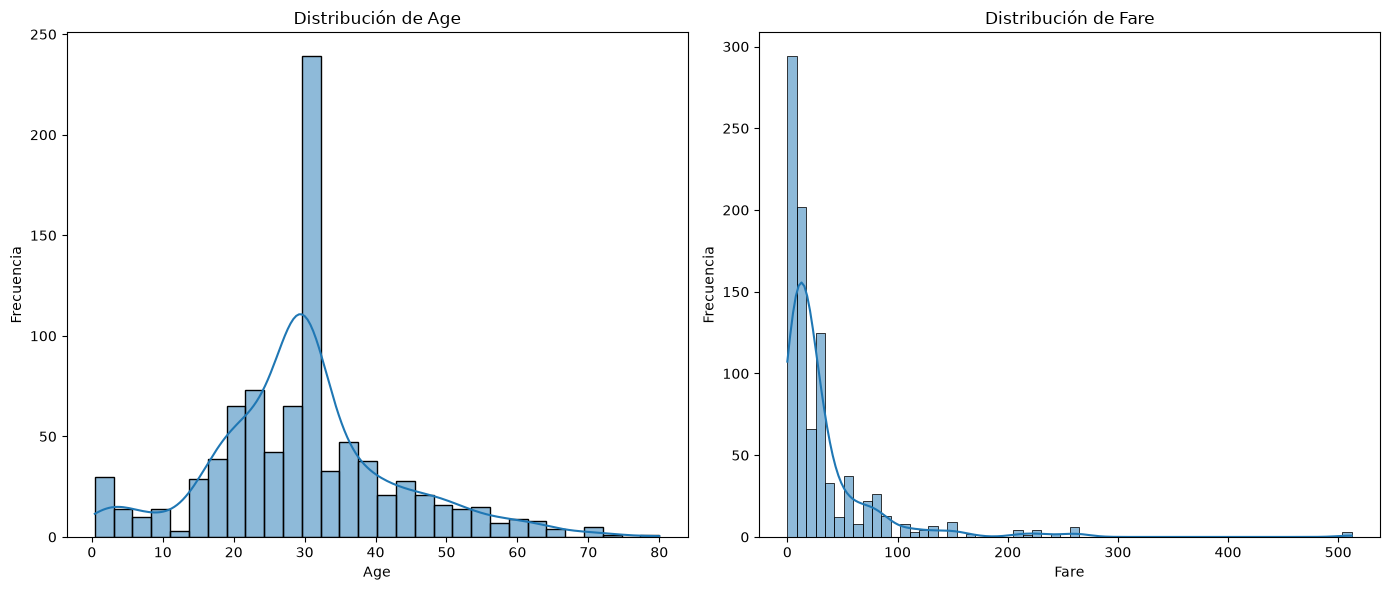

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfica de la distribución de Age
sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribución de Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frecuencia')

# Gráfica de la distribución de Fare
sns.histplot(df['Fare'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Distribución de Fare')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Scikit-Learn `QuantileTransformer`

Aplicaremos una transformación basada en cuantiles para aproximar `Age` y `Fare` a una distribución normal. Esta técnica limita la influencia de los valores extremos, especialmente en la cola larga de `Fare`.

In [8]:
qun_tra_age = QuantileTransformer(output_distribution='normal', n_quantiles=500)
qun_tra_fare = QuantileTransformer(output_distribution='normal', n_quantiles=500)

df['Age'] = qun_tra_age.fit_transform(df[['Age']]).ravel()
df['Fare'] = qun_tra_fare.fit_transform(df[['Fare']]).ravel()

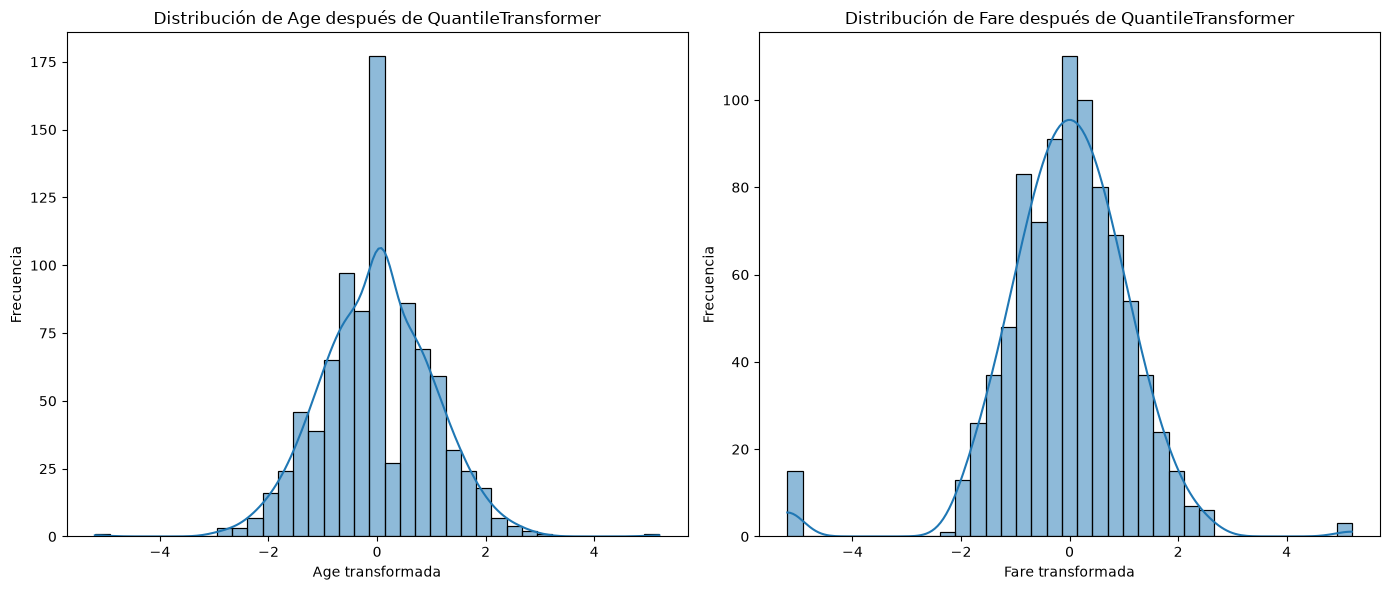

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df['Age'], kde=True, ax=axes[0])
axes[0].set_title('Distribución de Age después de QuantileTransformer')
axes[0].set_xlabel('Age transformada')
axes[0].set_ylabel('Frecuencia')

sns.histplot(df['Fare'], kde=True, ax=axes[1])
axes[1].set_title('Distribución de Fare después de QuantileTransformer')
axes[1].set_xlabel('Fare transformada')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [10]:
df[['Age', 'Fare']].describe().round(3)

,Age,Fare
count,891.000,891.000
mean,-0.001,-0.038
std,1.020,1.189
min,-5.199,-5.199
25%,-0.695,-0.693
50%,0.075,-0.005
75%,0.663,0.673
max,5.199,5.199


> **Importante:** los transformadores fueron ajustados con todo el DataFrame únicamente como ejercicio exploratorio. En un flujo de modelado riguroso deben ajustarse solo con los datos de entrenamiento, idealmente dentro de un `Pipeline`, para evitar fuga de información hacia el conjunto de prueba.

## Escalado con `MinMaxScaler`

`MinMaxScaler` aplica la fórmula $X_{escalado} = \frac{X-X_{min}}{X_{max}-X_{min}}$ para llevar los valores al rango `[0, 1]`.

### Explicación línea por línea

1. Cada instrucción `MinMaxScaler()` crea un escalador independiente. Esto permite que cada columna conserve sus propios valores mínimo y máximo.
2. `fit_transform(df[['columna']])` ajusta el escalador con el mínimo y máximo de esa columna y transforma sus valores al rango `[0, 1]`.
3. Se utilizan dobles corchetes para enviar a scikit-learn una matriz bidimensional de una columna.
4. `.ravel()` convierte el resultado nuevamente en un vector unidimensional antes de asignarlo al DataFrame.
5. Cada asignación reemplaza la columna original por su versión escalada.
6. `Survived` no se transforma porque es la variable objetivo binaria que queremos predecir.

In [11]:
mms_pclass = MinMaxScaler()
mms_sex = MinMaxScaler()
mms_age = MinMaxScaler()
mms_sibsp = MinMaxScaler()
mms_parch = MinMaxScaler()
mms_fare = MinMaxScaler()
mms_embarked = MinMaxScaler()

In [12]:
# Ejecutar transformaciones
df['Pclass'] = mms_pclass.fit_transform(df[['Pclass']]).ravel()
df['Sex'] = mms_sex.fit_transform(df[['Sex']]).ravel()
df['Age'] = mms_age.fit_transform(df[['Age']]).ravel()
df['SibSp'] = mms_sibsp.fit_transform(df[['SibSp']]).ravel()
df['Parch'] = mms_parch.fit_transform(df[['Parch']]).ravel()
df['Fare'] = mms_fare.fit_transform(df[['Fare']]).ravel()
df['Embarked'] = mms_embarked.fit_transform(df[['Embarked']]).ravel()

In [13]:
df.sample(5, random_state=42)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
709,1,1.0,1.0,0.507253,0.125,0.166667,0.504833,0.0
439,0,0.5,1.0,0.542129,0.000,0.000000,0.474087,1.0
840,0,1.0,1.0,0.416065,0.000,0.000000,0.438286,1.0
720,1,0.5,0.0,0.341914,0.000,0.166667,0.570274,1.0
39,1,1.0,0.0,0.366266,0.125,0.000000,0.478816,0.0


In [14]:
columnas_escaladas = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
rangos = pd.DataFrame({
    'Mínimo': df[columnas_escaladas].min(),
    'Máximo': df[columnas_escaladas].max()
})
print('Valores únicos de Survived:', sorted(df['Survived'].unique()))
rangos

Valores únicos de Survived: [np.int64(0), np.int64(1)]


,Mínimo,Máximo
Pclass,0.0,1.0
Sex,0.0,1.0
Age,0.0,1.0
SibSp,0.0,1.0
Parch,0.0,1.0
Fare,0.0,1.0
Embarked,0.0,1.0


> **Nota metodológica:** igual que con `QuantileTransformer`, este ajuste sobre todo `df` es demostrativo. Durante el entrenamiento real, los escaladores deben ajustarse únicamente con el conjunto de entrenamiento y reutilizarse sin reajustar sobre validación, prueba o nuevos pasajeros.

## Checkpoint

Guardamos el conjunto de datos procesado para utilizarlo en el notebook `4_machine_learning.ipynb`.

In [15]:
df.to_csv('./data/titanic_procesado.csv', index=False)

In [16]:
df_procesado = pd.read_csv('./data/titanic_procesado.csv')
print(f'Dimensiones: {df_procesado.shape[0]} filas y {df_procesado.shape[1]} columnas')
print(f'Valores nulos: {df_procesado.isnull().sum().sum()}')
df_procesado.head()

Dimensiones: 891 filas y 8 columnas
Valores nulos: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,1.0,1.0,0.433152,0.125,0.0,0.368146,1.0
1,1,0.0,0.0,0.579431,0.125,0.0,0.615097,0.0
2,1,1.0,0.0,0.462346,0.000,0.0,0.438286,1.0
3,1,0.0,0.0,0.563806,0.125,0.0,0.595112,1.0
4,0,1.0,1.0,0.563806,0.000,0.0,0.448347,1.0
